In [1]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel, RFECV
from scipy.stats import uniform, loguniform
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit

In [2]:
def fit_and_evaluate(model, x_tr, y_tr):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_validate(model, x_tr, y_tr, cv=kf, scoring='r2', return_train_score=True)

    mean_train_r2 = cv_scores['train_score'].mean()
    mean_val_r2 = cv_scores['test_score'].mean()

    return mean_train_r2, mean_val_r2

def comparison_plot(res):
    res_sorted = res.sort_values('Val R2', ascending=False)
    df_melted = res_sorted.melt(id_vars='Model',
                                value_vars=['Train R2', 'Val R2'],
                                var_name='Metric',
                                value_name='Score')

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

    plt.title('Порівняння ефективності моделей (Train vs Validation)', fontsize=16, pad=20)
    plt.ylabel('R2 Score (Коефіцієнт детермінації)', fontsize=12)
    plt.xlabel('Модель', fontsize=12)
    plt.ylim(0, 1.1)

    plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    plt.legend(title='Вибірка', loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.xticks(rotation=15, ha='right')

    plt.tight_layout()
    plt.show()

In [2]:
df = pd.read_csv("data/prepared_data.csv")
target_column = "Гострота зору некорегована далека відстань"

x = df.drop(columns=[target_column])
y = df[target_column]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=True, random_state=42)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(x, y, groups=df['Пацієнт']))

x_train = x.iloc[train_idx].copy()
x_test = x.iloc[test_idx].copy()

x_train.drop(columns=['Пацієнт'], inplace=True)
x_test.drop(columns=['Пацієнт'], inplace=True)

y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler = StandardScaler()
scaler.set_output(transform="pandas")
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

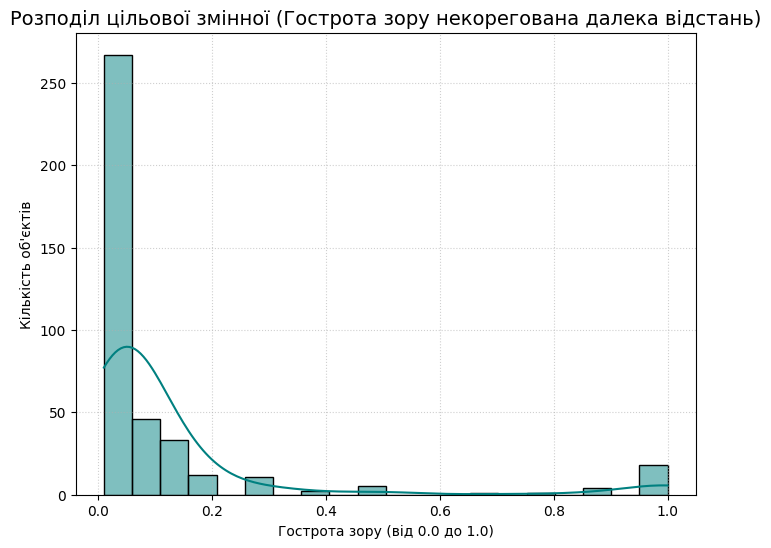

In [3]:
plt.figure(figsize=(8, 6))
sns.histplot(y, bins=20, kde=True, color='teal')
plt.title('Розподіл цільової змінної (Гострота зору некорегована далека відстань)', fontsize=14)
plt.xlabel('Гострота зору (від 0.0 до 1.0)')
plt.ylabel("Кількість об'єктів")
plt.grid(True, linestyle=':', alpha=0.6)

Аналіз розподілу цільової змінної показує, що дані не є збалансованими. Більшість об'єктів мають низьку гостроту зору, що є типовим для клінічної вибірки патологій.

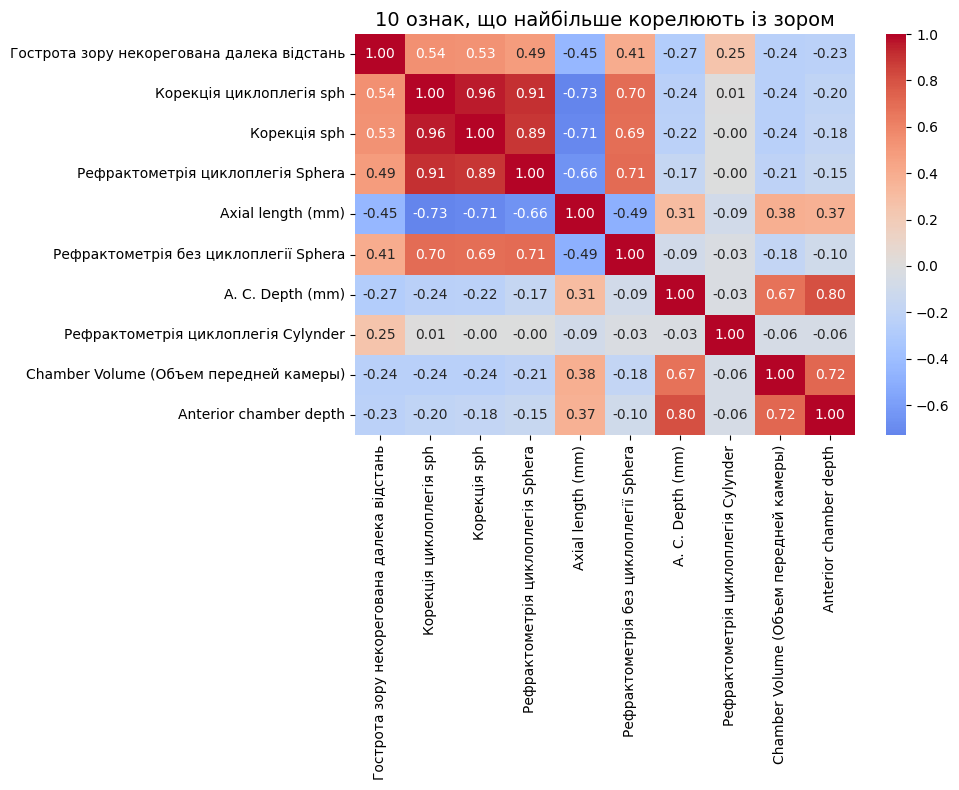

In [4]:
correlations = df.corr()[target_column].abs().sort_values(ascending=False)
top_features = correlations.head(10).index
top_corr_matrix = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('10 ознак, що найбільше корелюють із зором', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
elastic = ElasticNet()

r2_train_elastic, r2_val_elastic = fit_and_evaluate(elastic, x_train, y_train)

print("ElasticNet:")
print(f"   Train R2: {r2_train_elastic:.4f}")
print(f"   Val R2: {r2_val_elastic:.4f}")

ElasticNet:
   Train R2: 0.1052
   Val R2: -0.0068


In [14]:
grid = {
    'alpha': loguniform(1e-4, 100),
    'l1_ratio': uniform(0, 1),
    'max_iter': [1000, 2000, 5000]
}

elastic = ElasticNet(random_state=42)

elastic_random = RandomizedSearchCV(
    estimator=elastic,
    param_distributions=grid,
    n_iter=100,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42
)

elastic_random.fit(x_train_scaled, y_train)

print(f"\nНайкращі параметри: {elastic_random.best_params_}")

best_elastic = elastic_random.best_estimator_
r2_train_elastic, r2_val_elastic = fit_and_evaluate(best_elastic, x_train_scaled, y_train)

print("ElasticNet:")
print(f"   Train R2: {r2_train_elastic:.4f}")
print(f"   Val R2: {r2_val_elastic:.4f}")

C:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.758e-03, tolerance: 1.341e-03
  model = cd_fast.enet_coordinate_descent(


In [8]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

r2_train_rf, r2_val_rf = fit_and_evaluate(rf, x_train, y_train)

print("Random forest:")
print(f"   Train R2: {r2_train_rf:.4f}")
print(f"   Val R2: {r2_val_rf:.4f}")

Random forest:
   Train R2: 0.9752
   Val R2: 0.6844


In [9]:
grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}
rf = RandomForestRegressor(random_state=42)

rf_random = RandomizedSearchCV(estimator=rf,
                               param_distributions=grid,
                               n_iter=50,
                               cv=5,
                               verbose=1,
                               scoring='r2',
                               random_state=42)

rf_random.fit(x_train, y_train)

r2_train_rf, r2_val_rf = fit_and_evaluate(rf_random, x_train, y_train)

print("Random forest:")
print(f"   Train R2: {r2_train_rf:.4f}")
print(f"   Val R2: {r2_val_rf:.4f}")

Random forest:
   Train R2: 0.9528
   Val R2: 0.5407


In [10]:
print(f"\nНайкращі параметри: {rf_random.best_params_}")


Найкращі параметри: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 50}


In [11]:
nn = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=20000, random_state=42)

r2_train_nn, r2_val_nn = fit_and_evaluate(nn, x_train, y_train)

print(f"Neural network:")
print(f"   Train R2: {r2_train_nn:.4f}")
print(f"   Val R2: {r2_val_nn:.4f}")

Neural network:
   Train R2: -283.3910
   Val R2: -591.9745


In [12]:
grid = {
    'hidden_layer_sizes': [(30,), (50,), (100,), (30, 15), (50, 25), (100, 50)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['lbfgs', 'adam'],
    'alpha': loguniform(1e-5, 1e-1),
    'learning_rate_init': loguniform(1e-4, 1e-2)
}
nn = MLPRegressor(max_iter=5000, random_state=42)

nn_random = RandomizedSearchCV(
    estimator=nn,
    param_distributions=grid,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42
)

nn_random.fit(x_train_scaled, y_train)

print(f"\nНайкращі параметри: {nn_random.best_params_}")

best_nn = nn_random.best_estimator_

r2_train_nn, r2_val_nn = fit_and_evaluate(best_nn, x_train_scaled, y_train)

print(f"Neural Network")
print(f"   Train R2: {r2_train_nn:.4f}")
print(f"   Val R2:   {r2_val_nn :.4f}")

Neural Network
   Train R2: 0.9966
   Val R2:   0.6768


In [13]:
print(f"\nНайкращі параметри: {nn_random.best_params_}")


Найкращі параметри: {'activation': 'tanh', 'alpha': np.float64(0.07261414516028833), 'hidden_layer_sizes': (30, 15), 'learning_rate_init': np.float64(0.001217284708112243), 'solver': 'lbfgs'}


In [82]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=50)
elastic = ElasticNet(random_state=42, alpha=0.049, l1_ratio=0.994, max_iter=1000)
nn = MLPRegressor(activation='tanh', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.0726, learning_rate_init=0.00121, hidden_layer_sizes=(30, 15))

results = pd.DataFrame(columns=['Model', 'Train R2', 'Val R2'])

r2_train_elastic, r2_val_elastic = fit_and_evaluate(elastic, x_train_scaled, y_train)
r2_train_rf, r2_val_rf = fit_and_evaluate(rf, x_train_scaled, y_train)
r2_train_nn, r2_val_nn = fit_and_evaluate(nn, x_train_scaled, y_train)

results = pd.DataFrame(columns=['Model', 'Train R2', 'Val R2'])
results.loc[0] = ['ElasticNet (136)', r2_train_elastic, r2_val_elastic]
results.loc[1] = ['Random forest (136)', r2_train_rf, r2_val_rf]
results.loc[2] = ['Neural network (136)', r2_train_nn, r2_val_nn]
results

,Model,Train R2,Val R2
0,ElasticNet (136),0.244377,0.140512
1,Random forest (136),0.962298,0.654356
2,Neural network (136),0.996496,0.668189


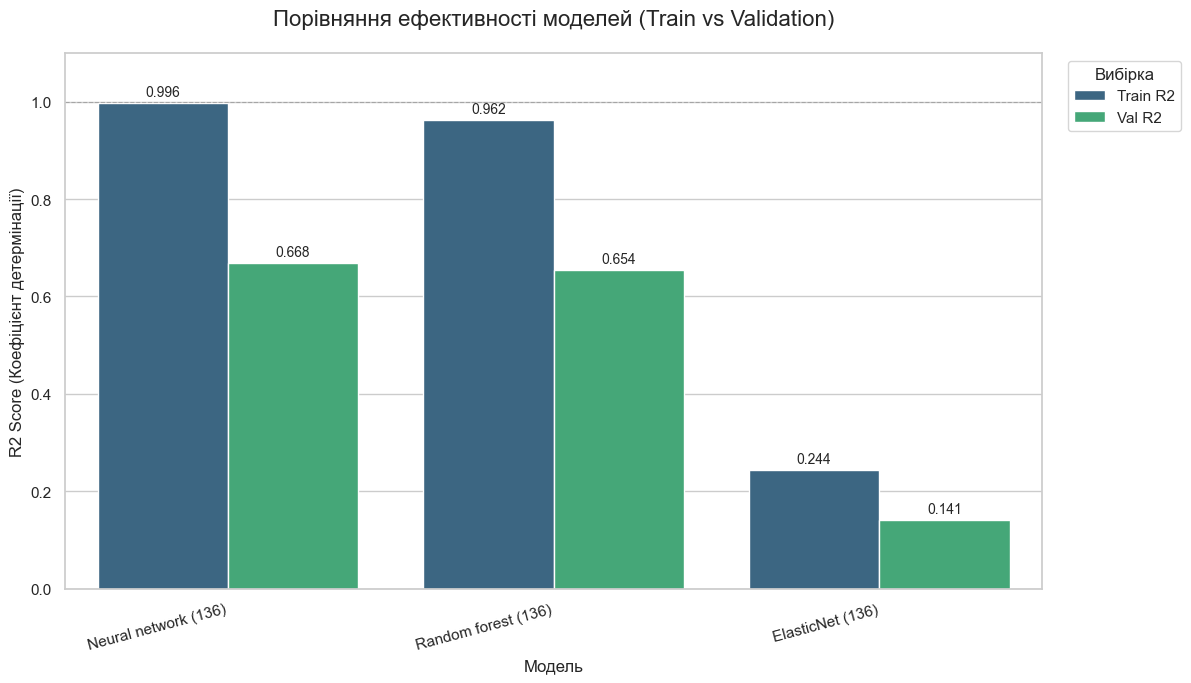

In [83]:
comparison_plot(results)

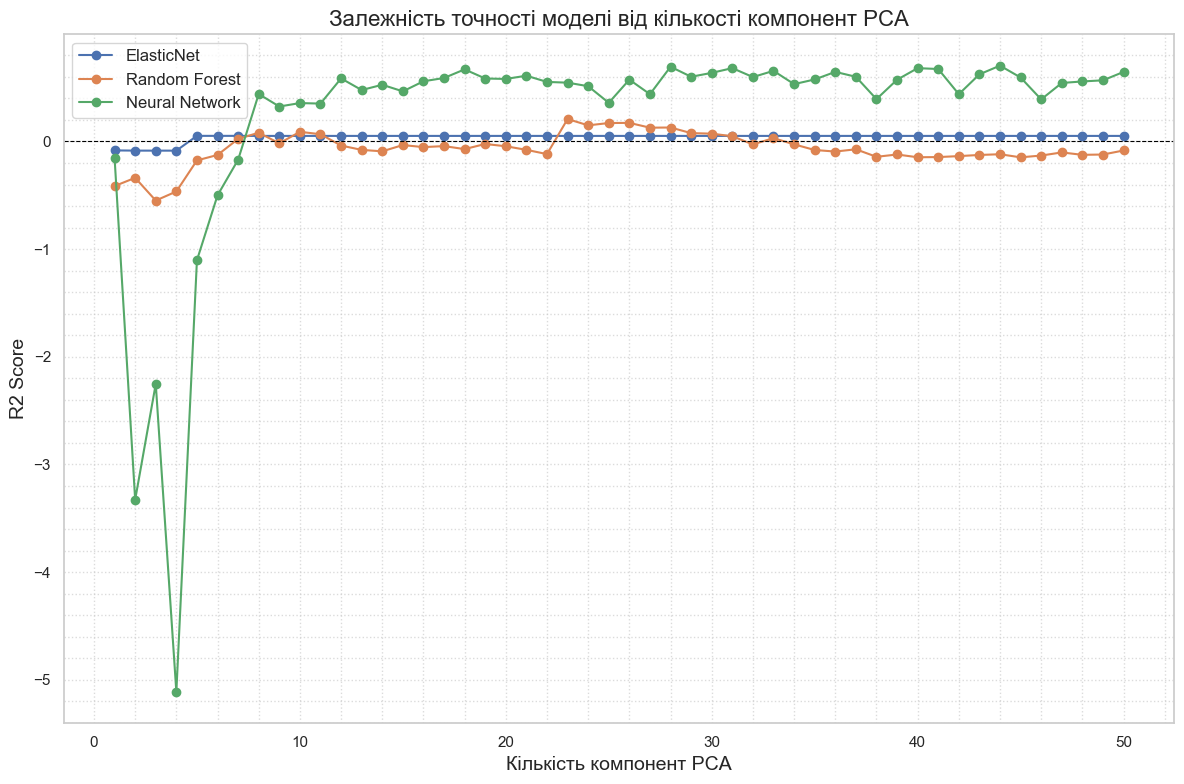

In [84]:
n_components_range = range(1, 51, 1)

scores = {'ElasticNet': [], 'Random Forest': [], 'Neural Network': []}

models = {
    'ElasticNet': elastic,
    'Random Forest': rf,
    'Neural Network': nn
}

for n in n_components_range:
    pca = PCA(n_components=n)
    x_pca = pca.fit_transform(x_train_scaled)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        _, r2_val = fit_and_evaluate(model, x_pca, y_train)
        scores[name].append(r2_val)

plt.figure(figsize=(12, 8))

for name, score_list in scores.items():
    plt.plot(n_components_range, score_list, marker='o', label=name)

plt.title('Залежність точності моделі від кількості компонент PCA', fontsize=16)
plt.xlabel('Кількість компонент PCA', fontsize=14)
plt.ylabel('R2 Score', fontsize=14)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.minorticks_on()
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [86]:
pca = PCA(n_components=23)
x_train_pca = pca.fit_transform(x_train_scaled)

results_pca = pd.DataFrame(columns=['Model', 'Train R2', 'Val R2'])

r2_train_elastic, r2_val_elastic = fit_and_evaluate(elastic, x_train_pca, y_train)
r2_train_rf, r2_val_rf = fit_and_evaluate(rf, x_train_pca, y_train)
r2_train_nn, r2_val_nn = fit_and_evaluate(nn, x_train_pca, y_train)

results_pca.loc[0] = ['ElasticNet PCA (23)', r2_train_elastic, r2_val_elastic]
results_pca.loc[1] = ['Random forest PCA (23)', r2_train_rf, r2_val_rf]
results_pca.loc[2] = ['Neural network PCA (23)', r2_train_nn, r2_val_nn]
results_pca

,Model,Train R2,Val R2
0,ElasticNet PCA (23),0.294678,0.051724
1,Random forest PCA (23),0.907980,0.208473
2,Neural network PCA (23),0.998840,0.546238


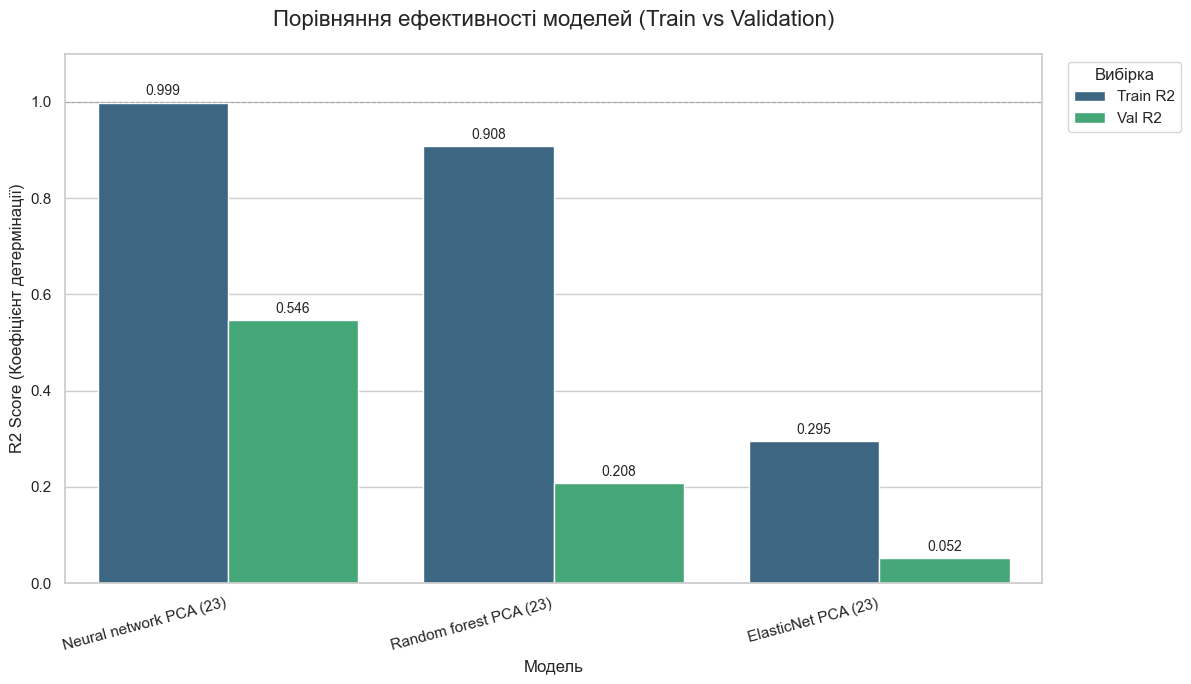

In [87]:
comparison_plot(results_pca)

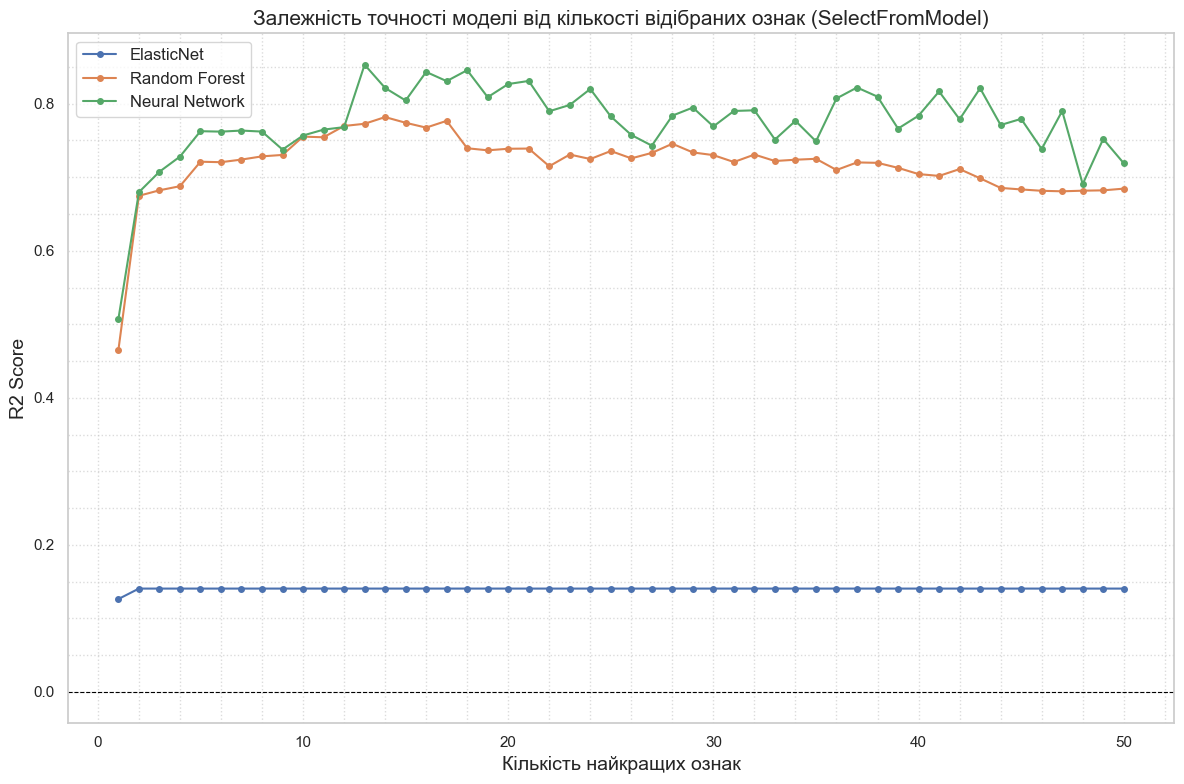

In [88]:
rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=50)
rf_selector.fit(x_train_scaled, y_train)

n_features_range = range(1, 51, 1)

scores = {'ElasticNet': [], 'Random Forest': [], 'Neural Network': []}

models = {
    'ElasticNet': elastic,
    'Random Forest': rf,
    'Neural Network': nn
}

for n in n_features_range:
    selector = SelectFromModel(rf_selector, threshold=-np.inf, max_features=n, prefit=True)

    x_selected = selector.transform(x_train_scaled)

    for name, model in models.items():
        _, r2_val = fit_and_evaluate(model, x_selected, y_train)
        scores[name].append(r2_val)

plt.figure(figsize=(12, 8))

for name, score_list in scores.items():
    plt.plot(n_features_range, score_list, marker='o', markersize=4, label=name)

plt.title('Залежність точності моделі від кількості відібраних ознак (SelectFromModel)', fontsize=15)
plt.xlabel('Кількість найкращих ознак', fontsize=14)
plt.ylabel('R2 Score', fontsize=14)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.minorticks_on()
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [89]:
rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=50)
rf_selector.fit(x_train_scaled, y_train)

selector = SelectFromModel(rf_selector, threshold=-np.inf, max_features=17, prefit=True)
selector.set_output(transform="pandas")

x_train_sel = selector.transform(x_train_scaled)

results_selected = pd.DataFrame(columns=['Model', 'Train R2', 'Val R2'])

r2_train_elastic, r2_val_elastic = fit_and_evaluate(elastic, x_train_sel, y_train)
r2_train_rf, r2_val_rf = fit_and_evaluate(rf, x_train_sel, y_train)
r2_train_nn, r2_val_nn = fit_and_evaluate(nn, x_train_sel, y_train)

results_selected.loc[0] = ['ElasticNet Selected (17)', r2_train_elastic, r2_val_elastic]
results_selected.loc[1] = ['Random forest Selected (17)', r2_train_rf, r2_val_rf]
results_selected.loc[2] = ['Neural network Selected (17)', r2_train_nn, r2_val_nn]
results_selected

,Model,Train R2,Val R2
0,ElasticNet Selected (17),0.244377,0.140512
1,Random forest Selected (17),0.966812,0.776700
2,Neural network Selected (17),0.983830,0.830695


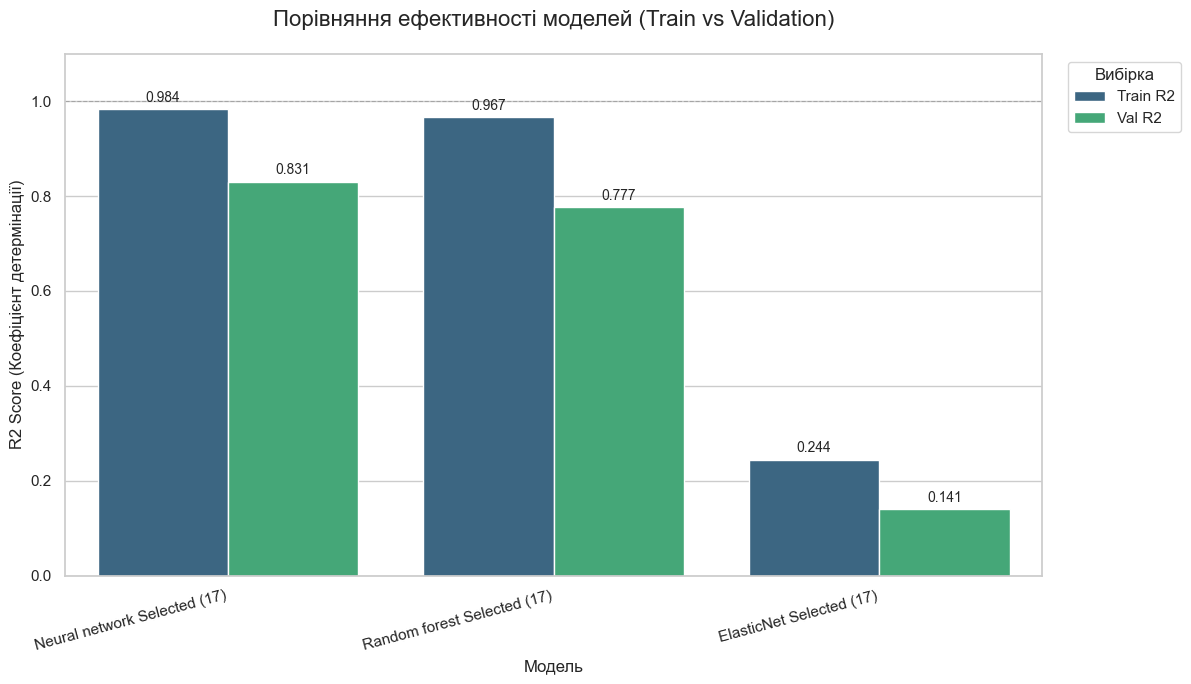

In [90]:
comparison_plot(results_selected)

In [91]:
rfecv = RFECV(estimator=rf, step=1, cv=KFold(5, shuffle=True, random_state=42), scoring='r2', min_features_to_select=5)

rfecv.fit(x_train, y_train)
selected_features = x_train.columns[rfecv.support_]
print(selected_features.tolist())

['Корекція sph', 'Корекція циклоплегія sph', 'Рефрактометрія циклоплегія Cylynder', 'Cornea Front Astig. (D) aстигматизм в центре роговицы', 'Cornea volume (Обьем роговицы)']


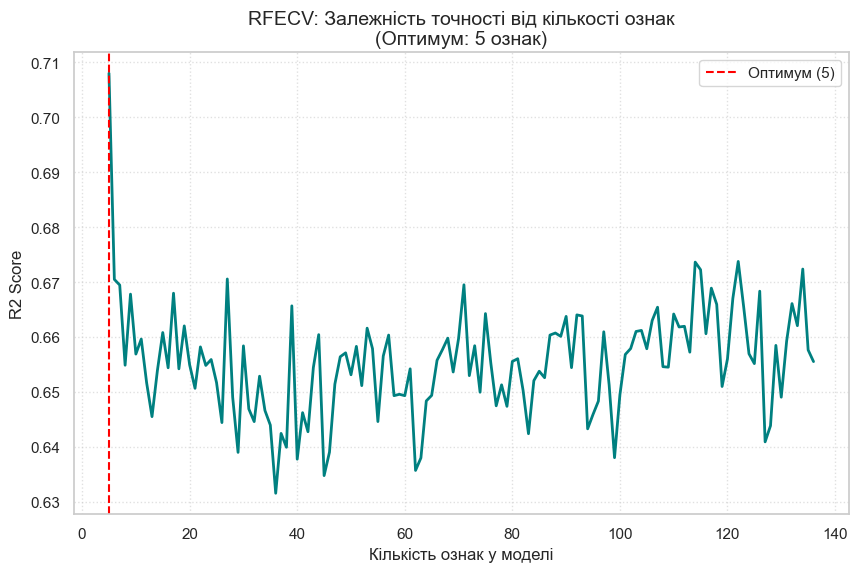

In [92]:
min_features = 5
plt.figure(figsize=(10, 6))
plt.xlabel("Кількість ознак у моделі")
plt.ylabel("R2 Score")

scores = rfecv.cv_results_['mean_test_score']
x_axis = range(min_features, len(scores) + min_features)
plt.plot(x_axis, scores, color='teal', linewidth=2)

plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Оптимум ({rfecv.n_features_})')

plt.title(f"RFECV: Залежність точності від кількості ознак\n(Оптимум: {rfecv.n_features_} ознак)", fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [96]:
#x_train_rfe = rfecv.transform(x_train_scaled)
x_train_rfe = x_train_scaled.loc[:, ['Корекція sph', 'Корекція циклоплегія sph', 'Рефрактометрія циклоплегія Cylynder', 'Cornea Front Astig. (D) aстигматизм в центре роговицы', 'Cornea volume (Обьем роговицы)']]

results_rfe = pd.DataFrame(columns=['Model', 'Train R2', 'Val R2'])

r2_train_elastic, r2_val_elastic = fit_and_evaluate(elastic, x_train_rfe, y_train)
r2_train_rf, r2_val_rf = fit_and_evaluate(rf, x_train_rfe, y_train)
r2_train_nn, r2_val_nn = fit_and_evaluate(nn, x_train_rfe, y_train)

results_rfe.loc[0] = ['ElasticNet RFE (5)', r2_train_elastic, r2_val_elastic]
results_rfe.loc[1] = ['Random forest RFE (5)', r2_train_rf, r2_val_rf]
results_rfe.loc[2] = ['Neural network RFE (5)', r2_train_nn, r2_val_nn]
results_rfe

,Model,Train R2,Val R2
0,ElasticNet RFE (5),0.244377,0.140512
1,Random forest RFE (5),0.962741,0.746261
2,Neural network RFE (5),0.935531,0.771394


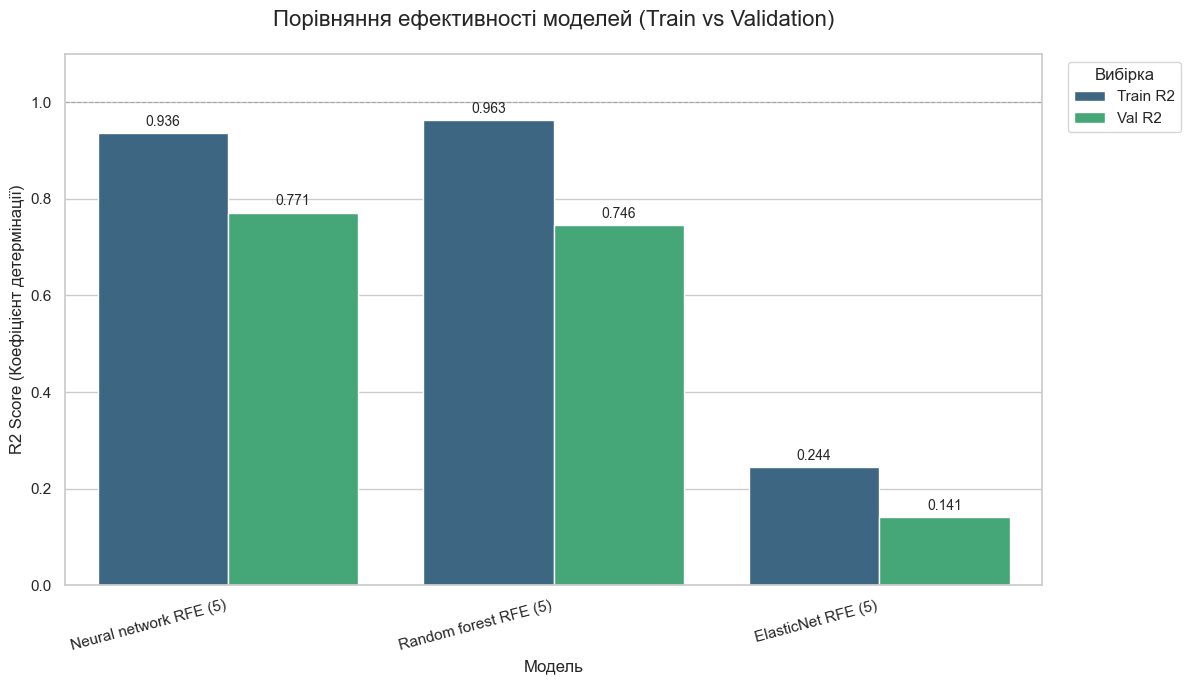

In [97]:
comparison_plot(results_rfe)

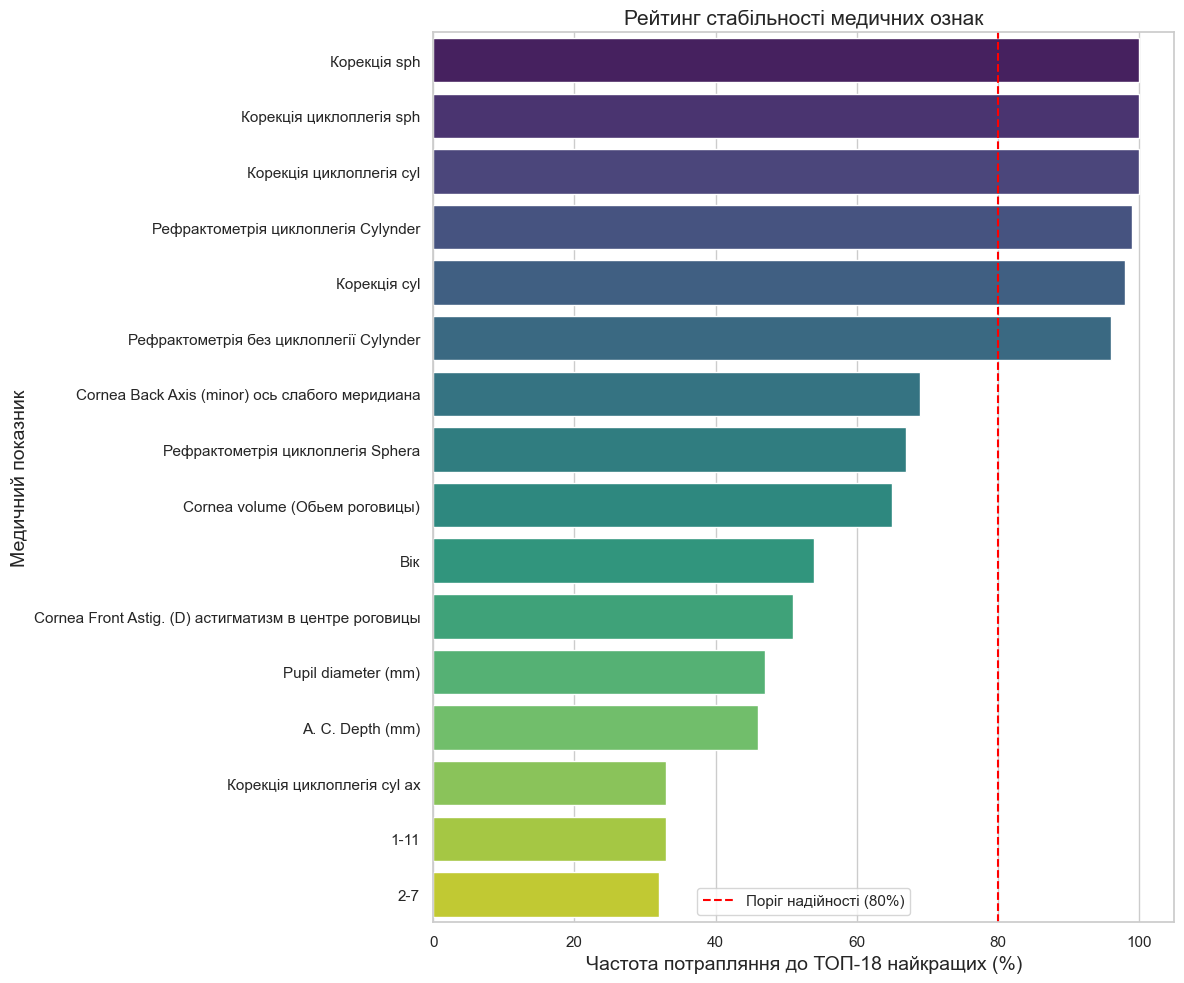

In [95]:
feature_names = x.columns
n_iterations = 100
top_n_features = 15

feature_counter = Counter()

for i in range(n_iterations):
    x_train_split, x_test_split, y_train_split, y_test_split = train_test_split(
        x, y, test_size=0.2, random_state=i
    )

    scaler = StandardScaler()
    x_train_scaled_split = scaler.fit_transform(x_train_split)

    rf_evaluator = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=50)

    rf_evaluator.fit(x_train_scaled_split, y_train_split)

    selector = SelectFromModel(rf_evaluator, threshold=-np.inf, max_features=top_n_features, prefit=True)

    selected_indices = selector.get_support(indices=True)
    selected_names = feature_names[selected_indices]

    feature_counter.update(selected_names)


stability_df = pd.DataFrame.from_dict(feature_counter, orient='index', columns=['Кількість виборів'])
stability_df['Стабільність (%)'] = (stability_df['Кількість виборів'] / n_iterations) * 100
stability_df = stability_df.sort_values(by='Стабільність (%)', ascending=False)

plt.figure(figsize=(12, 10))
plot_data = stability_df[stability_df['Стабільність (%)'] >= 30]

sns.barplot(x=plot_data['Стабільність (%)'], y=plot_data.index, palette='viridis')

plt.title(f'Рейтинг стабільності медичних ознак', fontsize=15)
plt.xlabel('Частота потрапляння до ТОП-18 найкращих (%)', fontsize=14)
plt.ylabel('Медичний показник', fontsize=14)
plt.axvline(x=80, color='red', linestyle='--', label='Поріг надійності (80%)')
plt.legend()
plt.tight_layout()
plt.show()

In [121]:
stability_df

,Кількість виборів,Стабільність (%)
Корекція sph,100,100.0
Корекція циклоплегія sph,100,100.0
Корекція циклоплегія cyl,100,100.0
Рефрактометрія циклоплегія Cylynder,99,99.0
Корекція cyl,98,98.0
...,...,...
горизонтальний 5,1,1.0
1-2,1,1.0
1-7,1,1.0
Кератометрія циклоплегії R2 mm,1,1.0


In [99]:
x_train_stable = x_train_scaled.loc[:, stability_df.index[:6].tolist()]

results_stable = pd.DataFrame(columns=['Model', 'Train R2', 'Val R2'])

r2_train_elastic, r2_val_elastic = fit_and_evaluate(elastic, x_train_stable , y_train)
r2_train_rf, r2_val_rf = fit_and_evaluate(rf, x_train_stable , y_train)
r2_train_nn, r2_val_nn = fit_and_evaluate(nn, x_train_stable , y_train)

results_stable.loc[0] = ['ElasticNet Stable (6)', r2_train_elastic, r2_val_elastic]
results_stable.loc[1] = ['Random forest Stable (6)', r2_train_rf, r2_val_rf]
results_stable.loc[2] = ['Neural network Stable (6)', r2_train_nn, r2_val_nn]
results_stable

,Model,Train R2,Val R2
0,ElasticNet Stable (6),0.244377,0.140512
1,Random forest Stable (6),0.949952,0.686688
2,Neural network Stable (6),0.927948,0.718664


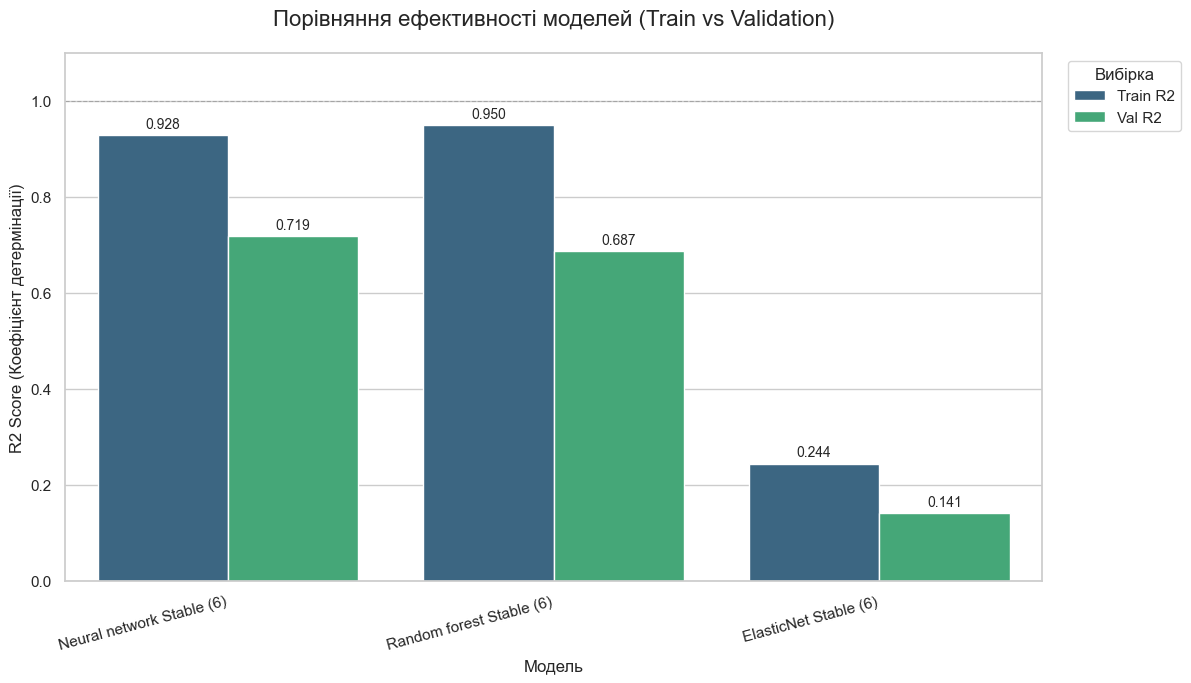

In [100]:
comparison_plot(results_stable)

In [101]:
results_full = pd.concat([results, results_pca, results_selected, results_rfe, results_stable], axis=0)
results_full['Перенавчання'] = results_full['Train R2'] - results_full['Val R2']
results_full

,Model,Train R2,Val R2,Перенавчання
0,ElasticNet (136),0.244377,0.140512,0.103865
1,Random forest (136),0.962298,0.654356,0.307942
2,Neural network (136),0.996496,0.668189,0.328307
0,ElasticNet PCA (23),0.294678,0.051724,0.242954
1,Random forest PCA (23),0.907980,0.208473,0.699506
2,Neural network PCA (23),0.998840,0.546238,0.452602
0,ElasticNet Selected (17),0.244377,0.140512,0.103865
1,Random forest Selected (17),0.966812,0.776700,0.190111
2,Neural network Selected (17),0.983830,0.830695,0.153135
0,ElasticNet RFE (5),0.244377,0.140512,0.103865


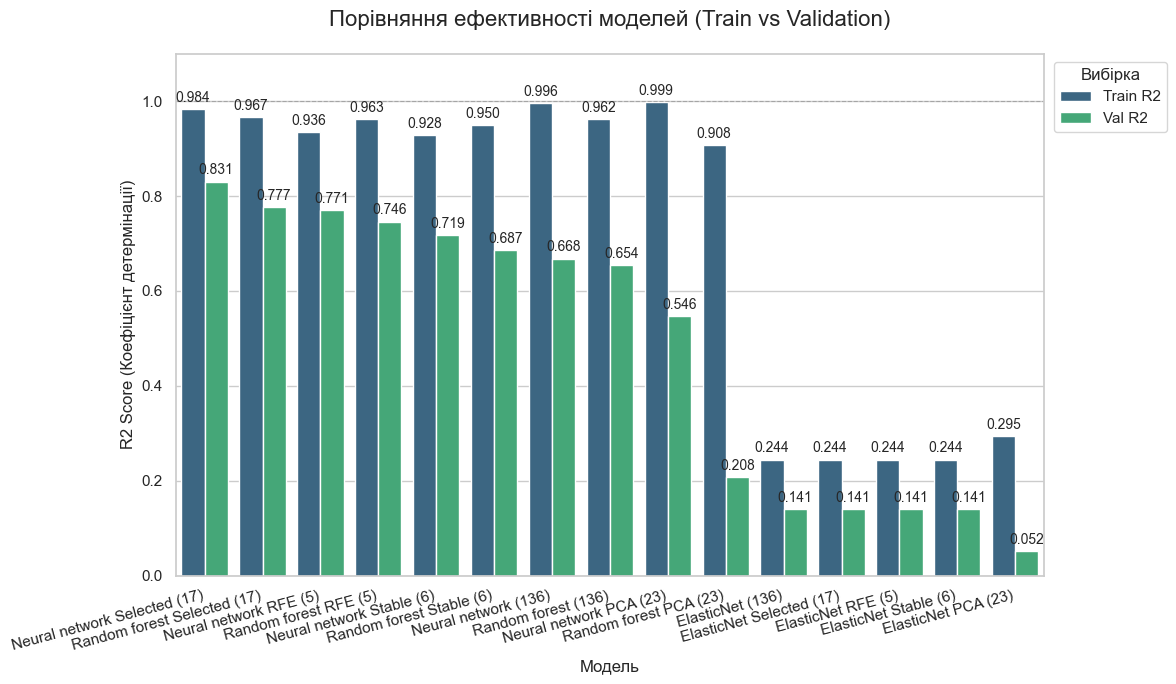

In [113]:
comparison_plot(results_full)

In [122]:
x_train_stable = x_train_scaled.loc[:, stability_df.index[:6].tolist()]
x_test_stable = x_test_scaled.loc[:, stability_df.index[:6].tolist()]

rf.fit(x_train_stable, y_train)
y_pred_test_rf = rf.predict(x_test_stable)

r2_test_rf = r2_score(y_test, y_pred_test_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

nn.fit(x_train_stable, y_train)
y_pred_test_nn = nn.predict(x_test_stable)

r2_test_nn = r2_score(y_test, y_pred_test_nn)
mae_test_nn = mean_absolute_error(y_test, y_pred_test_nn)
rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_pred_test_nn))

results_test_stable = pd.DataFrame(columns=['Model', 'Test R2', 'MAE', "RMSE"])

results_test_stable.loc[0] = ['Random Forest Stable (6)', r2_test_rf, mae_test_rf, rmse_test_rf]
results_test_stable.loc[1] = ['Neural Network Stable (6)', r2_test_nn, mae_test_nn, rmse_test_nn]

In [123]:
rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=50)
rf_selector.fit(x_train_scaled, y_train)

selector = SelectFromModel(rf_selector, threshold=-np.inf, max_features=17, prefit=True)
selector.set_output(transform="pandas")

x_train_sel = selector.transform(x_train_scaled)
x_test_sel = selector.transform(x_test_scaled)

rf.fit(x_train_sel, y_train)
y_pred_test_rf = rf.predict(x_test_sel)

r2_test_rf = r2_score(y_test, y_pred_test_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

nn.fit(x_train_sel, y_train)
y_pred_test_nn = nn.predict(x_test_sel)

r2_test_nn = r2_score(y_test, y_pred_test_nn)
mae_test_nn = mean_absolute_error(y_test, y_pred_test_nn)
rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_pred_test_nn))

results_test_selected = pd.DataFrame(columns=['Model', 'Test R2', 'MAE', "RMSE"])

results_test_selected.loc[0] = ['Random Forest Selected (17)', r2_test_rf, mae_test_rf, rmse_test_rf]
results_test_selected.loc[1] = ['Neural Network Selected (17)', r2_test_nn, mae_test_nn, rmse_test_nn]

C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [124]:
results_test = pd.concat([results_test_stable, results_test_selected], axis=0)
results_test

,Model,Test R2,MAE,RMSE
0,Random Forest Stable (6),0.878290,0.051030,0.097271
1,Neural Network Stable (6),0.692768,0.054034,0.154545
0,Random Forest Selected (17),0.857114,0.052545,0.105394
1,Neural Network Selected (17),0.488696,0.093528,0.199371


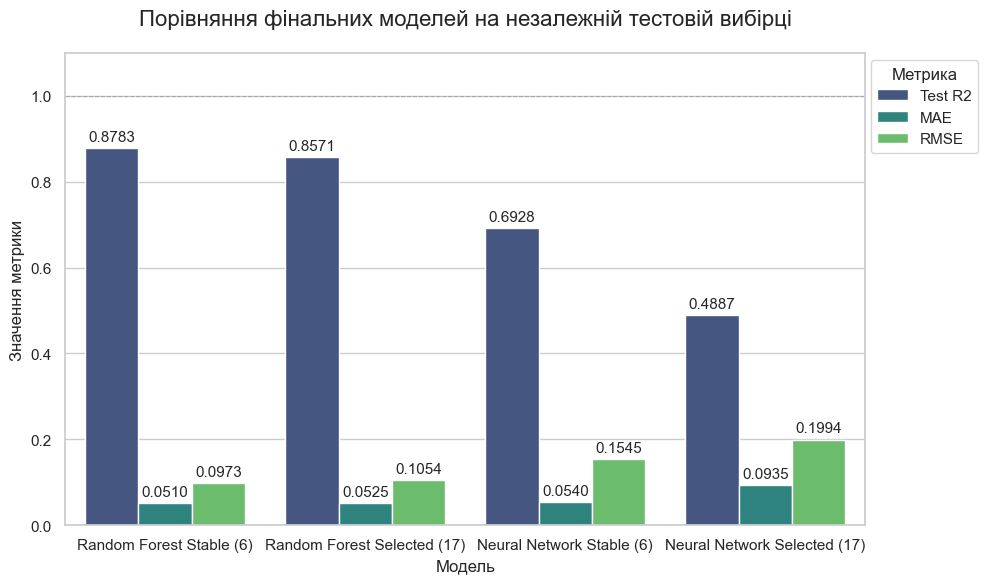

In [125]:
res_sorted = results_test.sort_values('Test R2', ascending=False)

df_melted = res_sorted.melt(id_vars='Model',
                            value_vars=['Test R2', 'MAE', 'RMSE'],
                            var_name='Metric',
                            value_name='Score')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=11)

plt.title('Порівняння фінальних моделей на незалежній тестовій вибірці', fontsize=16, pad=20)
plt.ylabel('Значення метрики', fontsize=12)
plt.xlabel('Модель', fontsize=12)

plt.ylim(0, 1.1)

plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.legend(title='Метрика', loc='upper right', bbox_to_anchor=(1.15, 1))

plt.xticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

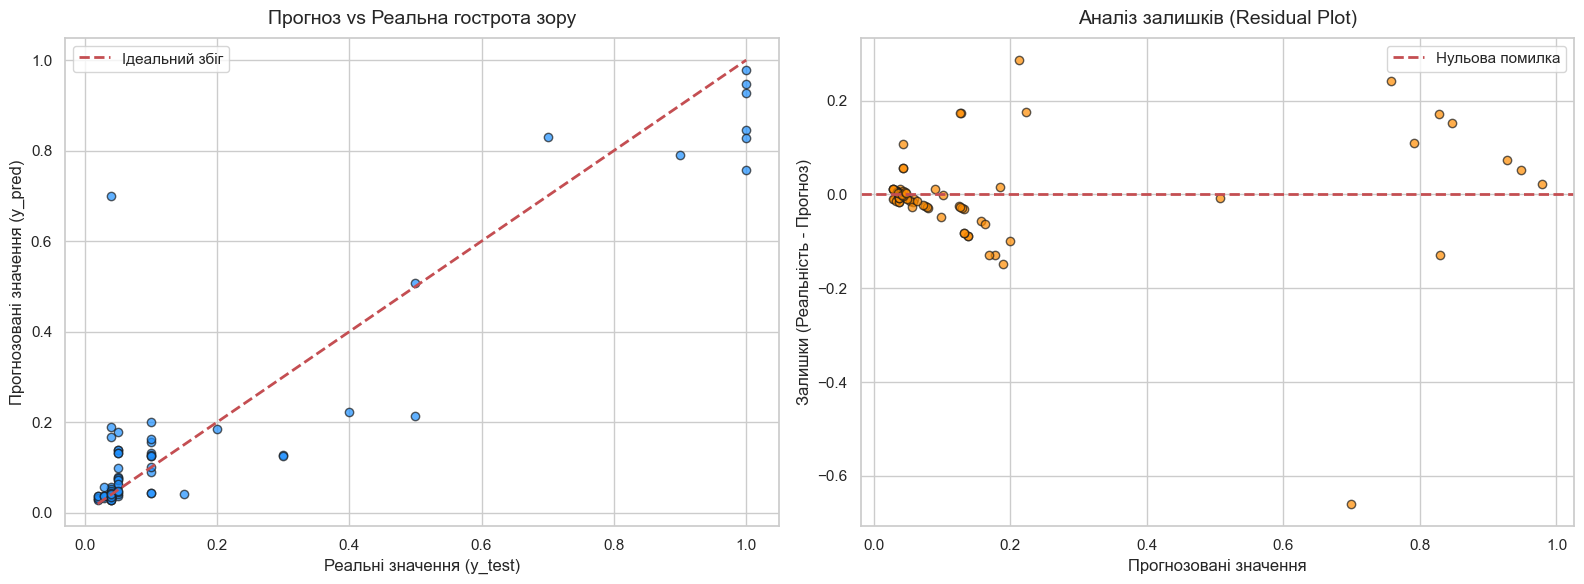

In [127]:
rf.fit(x_train_stable, y_train)
y_pred_test_rf = rf.predict(x_test_stable)
residuals = y_test - y_pred_test

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_test, alpha=0.7, color='dodgerblue', edgecolor='k')
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ідеальний збіг')
axes[0].set_title('Прогноз vs Реальна гострота зору', fontsize=14, pad=10)
axes[0].set_xlabel('Реальні значення (y_test)', fontsize=12)
axes[0].set_ylabel('Прогнозовані значення (y_pred)', fontsize=12)
axes[0].legend(fontsize=11)

axes[1].scatter(y_pred_test, residuals, alpha=0.7, color='darkorange', edgecolor='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Нульова помилка')
axes[1].set_title('Аналіз залишків (Residual Plot)', fontsize=14, pad=10)
axes[1].set_xlabel('Прогнозовані значення', fontsize=12)
axes[1].set_ylabel('Залишки (Реальність - Прогноз)', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()